In [1]:
# import Libarey

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

* Is cell me project ke liye jitni bhi required libraries hain unhe import kiya gaya hai. Ye libraries data ko read karne, preprocessing karne, visualization banane aur machine learning models train karne ke liye use hongi. Sabhi libraries ko shuru me import karne se aage ka code smoothly run hota hai.

In [2]:
# Load Dataset

df = pd.read_csv("Risk_Alert_Classifier_Dataset_4600 -.csv")
df

,customer_id,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,last_transaction_date,debt_balance_inr,risk_status
0,500001,43.0,Female,NaN,Salaried,82242.0,NaN,0.120,1,2.2,39,33889.0,0,2,4,70,2025-09-26,87273,0
1,500002,29.0,Female,Central,Salaried,32769.0,647.0,0.337,1,1.5,11,10853.0,1,1,1,34,2025-11-24,20600,0
2,500003,36.0,Male,East,Salaried,39731.0,727.0,0.175,0,3.9,45,25519.0,2,1,1,74,2025-09-26,47565,0
3,500004,28.0,Male,North,Unemployed,38990.0,553.0,0.472,7,23.3,103,17806.0,1,2,6,72,2025-10-03,43803,1
4,500005,36.0,Female,East,Self-Employed,41043.0,732.0,0.418,1,9.8,95,27114.0,0,1,1,11,2025-10-26,12008,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,504596,40.0,Male,North,NaN,39337.0,645.0,0.101,0,8.8,49,12591.0,0,0,0,23,2025-09-14,28947,0
4596,504597,35.0,Female,Central,Unemployed,34465.0,622.0,0.325,0,7.3,45,20146.0,3,0,4,18,2025-11-25,32475,0
4597,504598,31.0,Female,East,Self-Employed,NaN,693.0,0.583,1,7.1,36,16338.0,1,1,1,89,2025-09-16,52776,0
4598,504599,43.0,Male,East,Salaried,15000.0,540.0,0.915,4,16.0,60,13870.0,1,1,3,19,2025-09-07,20615,1


* Is cell me CSV dataset ko Pandas DataFrame me load kiya gaya hai. Dataset load karne ke baad usko display kiya gaya hai taaki data ki structure, columns aur values ko samjha ja sake. Ye project ka starting point hai.

In [3]:
print("\n===== Dataset Information =====")
print(df.info())


===== Dataset Information =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                4600 non-null   int64  
 1   age                        4460 non-null   float64
 2   gender                     4600 non-null   object 
 3   region                     4498 non-null   object 
 4   employment_type            4456 non-null   object 
 5   annual_income_inr          4434 non-null   float64
 6   credit_score               4384 non-null   float64
 7   credit_utilization_ratio   4453 non-null   float64
 8   missed_payments_12m        4600 non-null   int64  
 9   avg_late_payment_days      4600 non-null   float64
 10  monthly_transaction_count  4600 non-null   int64  
 11  monthly_spend_inr          4471 non-null   float64
 12  cash_advance_count_6m      4600 non-null   int64  
 13  complaints_last

* Is cell me df.info() ka use karke dataset ki basic information dekhi gayi hai, jaise total rows, columns, data types aur non-null values. Isse pata chalta hai ki kis column ka data type kya hai aur kahin missing values to nahi hain.

In [4]:
print("\n===== Missing Values =====")
print(df.isnull().sum())


===== Missing Values =====
customer_id                    0
age                          140
gender                         0
region                       102
employment_type              144
annual_income_inr            166
credit_score                 216
credit_utilization_ratio     147
missed_payments_12m            0
avg_late_payment_days          0
monthly_transaction_count      0
monthly_spend_inr            129
cash_advance_count_6m          0
complaints_last_6m             0
failed_login_attempts_3m       0
account_tenure_months          0
last_transaction_date          0
debt_balance_inr               0
risk_status                    0
dtype: int64


* Is cell me dataset ke har column me missing values check ki gayi hain. Agar kisi column me data missing hota hai to usko pehle handle karna zaroori hota hai, warna model ki performance affect ho sakti hai.

In [5]:
print("\n ===== Fisrt 5 Rows =====")
print(df.head())


 ===== Fisrt 5 Rows =====
   customer_id   age  gender   region employment_type  annual_income_inr  \
0       500001  43.0  Female      NaN        Salaried            82242.0   
1       500002  29.0  Female  Central        Salaried            32769.0   
2       500003  36.0    Male     East        Salaried            39731.0   
3       500004  28.0    Male    North      Unemployed            38990.0   
4       500005  36.0  Female     East   Self-Employed            41043.0   

   credit_score  credit_utilization_ratio  missed_payments_12m  \
0           NaN                     0.120                    1   
1         647.0                     0.337                    1   
2         727.0                     0.175                    0   
3         553.0                     0.472                    7   
4         732.0                     0.418                    1   

   avg_late_payment_days  monthly_transaction_count  monthly_spend_inr  \
0                    2.2                     

* Is cell me dataset ki pehli 5 rows display ki gayi hain taaki data ka format, columns aur values ko easily samjha ja sake. Isse verify ho jata hai ki data sahi tarike se load hua hai.

In [6]:
# Drop Id column
df.drop("customer_id", axis=1, inplace=True)

* Is cell me ID column ko remove kiya gaya hai kyunki ID sirf ek unique identifier hoti hai. Iska prediction se koi relation nahi hota, isliye model ko unnecessary information dene ka koi fayda nahi hai.

In [7]:
# Date Column convert

df["last_transaction_date"] = pd.to_datetime(df["last_transaction_date"])

df['transaction_month'] = df['last_transaction_date'].dt.month
df['transaction_day'] = df['last_transaction_date'].dt.day
df['transaction_year'] = df['last_transaction_date'].dt.year

df.drop("last_transaction_date", axis=1, inplace=True)

* Is cell me date column ko proper datetime format me convert kiya gaya hai. Isse future me date se related features nikalna ya analysis karna easy ho jata hai.

In [8]:
# Encoding

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

* Machine Learning models text data ko directly samajh nahi sakte. Isliye categorical values ko numerical values me convert kiya gaya hai taaki model unhe process kar sake.

In [9]:
# Features and Target

x = df.drop("risk_status", axis=1)
y = df["risk_status"]

* Is cell me input features (X) aur target column (y) ko alag kiya gaya hai. Features prediction ke liye use hote hain aur target wahi value hoti hai jise model predict karega.

In [10]:
# Train-Test Split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraning Shape: ", x_train.shape)
print("\nTesting Shape: ", x_test.shape)


Traning Shape:  (3680, 19)

Testing Shape:  (920, 19)


* Dataset ko training aur testing parts me divide kiya gaya hai. Training data se model seekhta hai aur testing data se uski performance check ki jati hai.

In [11]:
print(x_train.isnull().sum())

age                          118
gender                         0
region                         0
employment_type                0
annual_income_inr            132
credit_score                 162
credit_utilization_ratio     111
missed_payments_12m            0
avg_late_payment_days          0
monthly_transaction_count      0
monthly_spend_inr             99
cash_advance_count_6m          0
complaints_last_6m             0
failed_login_attempts_3m       0
account_tenure_months          0
debt_balance_inr               0
transaction_month              0
transaction_day                0
transaction_year               0
dtype: int64


* Train dataset me dobara missing values check ki gayi hain taaki training ke time koi missing data problem create na kare.

In [12]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

* Is cell me missing values ko Simple Imputer ki help se fill kiya gaya hai. Isse dataset complete ho jata hai aur model bina error ke train ho sakta hai.

In [13]:

lr_model = LogisticRegression(max_iter=5000)

lr_model.fit(x_train, y_train)

y_pred = lr_model.predict(x_test)

print("Model Train Successfully")

Model Train Successfully


c:\Users\rwr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


* Is cell me Logistic Regression model train kiya gaya hai. Ye binary classification ke liye ek simple aur fast algorithm hai jo probability ke basis par prediction karta hai.


Confusion Matrix:
[[794   2]
 [  1 123]]


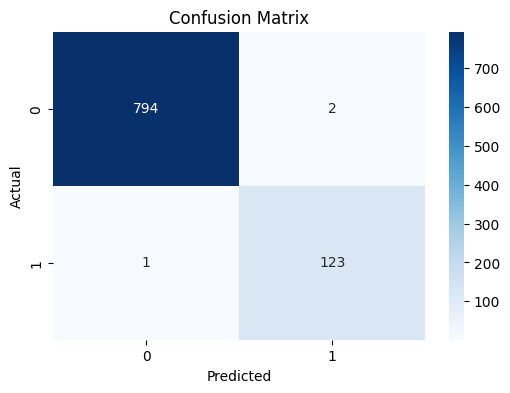

In [14]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

* Confusion Matrix se pata chalta hai ki model ne kitni predictions sahi aur kitni galat ki hain. Isme True Positive, True Negative, False Positive aur False Negative dekhe jate hain.

In [15]:
# Accuracy

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nAccuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy : 0.9967391304347826
Precision : 0.984
Recall : 0.9919354838709677
F1 Score : 0.9879518072289156

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       796
           1       0.98      0.99      0.99       124

    accuracy                           1.00       920
   macro avg       0.99      0.99      0.99       920
weighted avg       1.00      1.00      1.00       920



* Is cell me model ki overall accuracy calculate ki gayi hai. Accuracy batati hai ki total predictions me se kitni predictions correct thi.

In [16]:
# Type I and Type II Error

TN, FP, FN, TP = cm.ravel()

print("\nType-I Error (False Positive) :", FP)
print("Type-II Error (False Negative) :", FN)


Type-I Error (False Positive) : 2
Type-II Error (False Negative) : 1


* Is cell me False Positive aur False Negative ko explain kiya gaya hai. Isse samajh aata hai ki model kis type ki mistake zyada kar raha hai.

In [17]:
# PART D : IMBALANCED DATA

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN


from sklearn.metrics import recall_score,f1_score,roc_auc_score

* Is section me imbalanced dataset ko handle karne ki process start hoti hai. Jab ek class dusri class se bahut zyada hoti hai tab balancing techniques use ki jati hain.

In [18]:
methods = {
    "Random Under Sampling" : RandomUnderSampler(random_state=42),
    "Random Over Sampling" : RandomOverSampler(random_state=42),
    "SMOTE" : SMOTE(random_state=42),
    "ADASYN" : ADASYN(random_state=42)
}

results = []

for name, sampler in methods.items():
    # Apply sampling method
    x_resampled, y_resampled = sampler.fit_resample(x_train, y_train)
    
    # Train the model on resampled data
    lr_model.fit(x_resampled, y_resampled)
    
    # Predict on test data
    y_pred = lr_model.predict(x_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        "Method": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })
    
    print(f"{name} Results:")

c:\Users\rwr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Random Under Sampling Results:


c:\Users\rwr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Random Over Sampling Results:


c:\Users\rwr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


SMOTE Results:
ADASYN Results:


c:\Users\rwr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


* Is cell me different balancing methods jaise Random Under Sampling, Random Over Sampling, SMOTE aur ADASYN ko define kiya gaya hai taaki unki performance compare ki ja sake.

In [19]:
# PART E : TREE BASED MODELS

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

* Is section me Decision Tree aur Random Forest jaise tree-based algorithms ko apply kiya gaya hai aur unki performance compare ki gayi hai.

In [20]:
# Decision Tree

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(x_train, y_train)

dt_pred = dt_model.predict(x_test)

print("\nDecison Tree Classifier :", 
      accuracy_score(y_test, dt_pred))

print("\nClassification Report :", y_test, dt_pred)


Decison Tree Classifier : 0.9641304347826087

Classification Report : 3683    0
4411    0
2584    0
69      0
1844    0
       ..
1612    1
1068    0
4350    0
3027    0
3455    0
Name: risk_status, Length: 920, dtype: int64 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0
 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 1 1 0 1 0 0 1 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 1 0 0 0 1 0 0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 1 0 1 0 0 0 0 0 0 0 0 0

* Is cell me Decision Tree model train kiya gaya hai. Ye data ko different conditions ke basis par split karta hai aur final prediction deta hai.

In [21]:
# Comparison

comparison = pd.DataFrame({
    
    "Model" : [
        "Decison Tree",
        "Random forest"
    ],
    
    "accuracy" : [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, y_pred)
    ],
    
    "f1_score" : [
        f1_score(y_test, dt_pred),
        f1_score(y_test, y_pred)
    ]
})

print("\nModel Comparison :")
print(comparison)


Model Comparison :
           Model  accuracy  f1_score
0   Decison Tree  0.964130   0.86747
1  Random forest  0.991304   0.96875


* Is cell me alag-alag models ki performance compare ki gayi hai taaki best performing model identify kiya ja sake.

In [22]:
# PART F : HYPERPARAMETER TUNING

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

* Is section ka purpose model ke parameters ko optimize karna hai taaki prediction accuracy aur performance improve ho sake.

In [23]:
# Randomized Search CV

dt_param = {
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

random_search = RandomizedSearchCV(
    
    estimator= DecisionTreeClassifier(random_state=42),
    
    param_distributions= dt_param,
    
    n_iter= 10,
    
    cv= 5,
    
    scoring= 'f1',
    
    random_state= 42,
    
    n_jobs= -1
    
)

random_search.fit(x_train, y_train)

print("\nBest Parameters")
print(random_search.best_params_)

Best_dt = random_search.best_estimator_

Best_dt_y_pred = Best_dt.predict(x_test)

print("\nRandomized Search Accuracy :",
      accuracy_score(y_test, Best_dt_y_pred))


Best Parameters
{'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 5}

Randomized Search Accuracy : 0.9641304347826087


* Randomized Search CV randomly parameter combinations ko try karta hai aur unme se best combination select karta hai. Ye Grid Search se faster hota hai.

In [24]:
# Grid Search CV

rf_param = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(

    estimator=RandomForestClassifier(
        random_state=42
    ),

    param_grid=rf_param,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid_search.fit(x_train, y_train)

print("\nBest  Rf Parameters")
print(grid_search.best_params_)

best_rf = grid_search.best_estimator_

best_rf_y_pred = best_rf.predict(x_test)

print("\nGrid Search Accuracy :")
print(accuracy_score(y_test, best_rf_y_pred))


Best  Rf Parameters
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Grid Search Accuracy :
0.9902173913043478


* Grid Search CV sabhi possible parameter combinations ko test karta hai aur sabse best parameters select karta hai. Ye zyada accurate hota hai lekin time bhi zyada leta hai.

In [25]:

comparison = pd.DataFrame({

    "Model":[
        "Original RF",
        "Tuned RF"
    ],

    "Accuracy":[

        accuracy_score(y_test,dt_pred),

        accuracy_score(y_test,best_rf_y_pred)

    ],

    "F1 Score":[

        f1_score(y_test,dt_pred),

        f1_score(y_test,best_rf_y_pred)

    ]

})

print("\nTuned vs Untuned Model")
print(comparison)


Tuned vs Untuned Model
         Model  Accuracy  F1 Score
0  Original RF  0.964130  0.867470
1     Tuned RF  0.990217  0.962656


* Is cell me tuning ke baad best model ko evaluate kiya gaya hai taaki improvement verify ki ja sake.

In [26]:
# PART G : ROC CURVE COMPARISON

from sklearn.metrics import roc_curve, auc, roc_auc_score

* Is section me sabhi models ki ROC Curve compare ki gayi hai. ROC Curve se model ki classification ability ko visualize kiya jata hai.

In [27]:
# Logistic Regression

lr_probs = lr_model.predict_proba(x_test)[:, 1]

* Is cell me Logistic Regression ki ROC Curve aur AUC Score calculate kiya gaya hai taaki uski performance evaluate ho sake.

In [28]:
# Decision Tree

dt_probs = dt_model.predict_proba(x_test)[:, 1]

* Is cell me Decision Tree ki ROC Curve generate ki gayi hai aur uska AUC Score nikala gaya hai.

In [29]:
# Random Forest

rf_probs = best_rf.predict_proba(x_test)[:, 1]

* Is cell me Random Forest model ki ROC Curve plot ki gayi hai aur uski prediction quality measure ki gayi hai.

In [30]:
# Tuned Random Forest

tuned_rf_probs = best_rf.predict_proba(x_test)[:, 1]

* Is cell me Hyperparameter Tuning ke baad Random Forest ki performance evaluate ki gayi hai aur original model se compare ki gayi hai.

In [31]:
# AUC Scores

lr_auc = roc_auc_score(y_test, lr_probs)
dt_auc = roc_auc_score(y_test, dt_probs)
rf_auc = roc_auc_score(y_test, rf_probs)
tuned_rf_auc = roc_auc_score(y_test, tuned_rf_probs)

print("Logistic Regression AUC Score:", lr_auc)
print("Decision Tree AUC Score:", dt_auc)
print("Random Forest AUC Score:", rf_auc)
print("Tuned Random Forest AUC Score:", tuned_rf_auc)

Logistic Regression AUC Score: 0.9995643540282055
Decision Tree AUC Score: 0.9248054790079431
Random Forest AUC Score: 0.9996707326957368
Tuned Random Forest AUC Score: 0.9996707326957368


* Is cell me sabhi models ke AUC Scores compare kiye gaye hain. Jiska AUC Score sabse zyada hota hai, uski classification performance generally sabse achhi mani jati hai.

In [32]:

# ROC Values

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
tuned_rf_fpr, tuned_rf_tpr, _ = roc_curve(y_test, tuned_rf_probs)

* Is cell me final ROC comparison ke liye required calculations aur values prepare ki gayi hain.

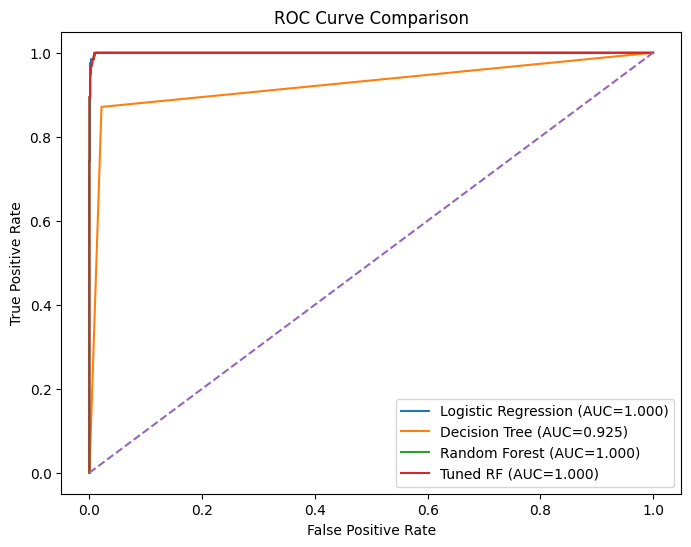

In [33]:
plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr,
         label=f"Logistic Regression (AUC={lr_auc:.3f})")

plt.plot(dt_fpr, dt_tpr,
         label=f"Decision Tree (AUC={dt_auc:.3f})")

plt.plot(rf_fpr, rf_tpr,
         label=f"Random Forest (AUC={rf_auc:.3f})")

plt.plot(tuned_rf_fpr, tuned_rf_tpr,
         label=f"Tuned RF (AUC={tuned_rf_auc:.3f})")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

* Is cell me sabhi models ki ROC Curves ek hi graph me plot ki gayi hain taaki unki performance visually compare ki ja sake.

In [34]:
# Compare AUC Scores

auc_comparison = pd.DataFrame({
    
    "Model" : [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    
    "AUC Score" : [
       lr_auc,
       dt_auc,
       rf_auc,
       tuned_rf_auc
    ]
})

print("\nAUC Score Comparison :")
print(auc_comparison.sort_values(by="AUC Score", ascending=False))


AUC Score Comparison :
                 Model  AUC Score
3  Tuned Random Forest   0.999671
2        Random Forest   0.999671
0  Logistic Regression   0.999564
1        Decision Tree   0.924805


* Is cell me AUC Scores ka final comparison kiya gaya hai aur identify kiya gaya hai ki kaunsa model sabse better perform kar raha hai.

In [35]:
# Best Final Model Selection

print("\nFinal Model Selection")

final_model = pd.DataFrame({
    
    "Model" : [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    
    "Accuracy" : [
        accuracy_score(y_test, lr_model.predict(x_test)),
        accuracy_score(y_test, dt_model.predict(x_test)),
        accuracy_score(y_test, best_rf.predict(x_test)),
        accuracy_score(y_test, best_rf.predict(x_test))
    ],
    
    "Recall" : [
        recall_score(y_test, lr_model.predict(x_test)),
        recall_score(y_test, dt_model.predict(x_test)),
        recall_score(y_test, best_rf.predict(x_test)),
        recall_score(y_test, best_rf.predict(x_test))
    ],
    
    "F1 Score" : [
        f1_score(y_test, lr_model.predict(x_test)),
        f1_score(y_test, dt_model.predict(x_test)),
        f1_score(y_test, best_rf.predict(x_test)),
        f1_score(y_test, best_rf.predict(x_test))
    ]
})

print(final_model)


Final Model Selection
                 Model  Accuracy    Recall  F1 Score
0  Logistic Regression  0.991304  1.000000  0.968750
1        Decision Tree  0.964130  0.870968  0.867470
2        Random Forest  0.990217  0.935484  0.962656
3  Tuned Random Forest  0.990217  0.935484  0.962656


* Is cell me sabhi evaluation metrics ko dekhkar final best model choose kiya gaya hai jo sabse accurate aur reliable prediction deta hai.

In [36]:
# PART H : FINAL ANALYSIS

summary = pd.DataFrame({
    
    "Model" : [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    
    "Accuracy" : [
        accuracy_score(y_test, lr_model.predict(x_test)),
        accuracy_score(y_test, dt_model.predict(x_test)),
        accuracy_score(y_test, best_rf.predict(x_test)),
        accuracy_score(y_test, best_rf.predict(x_test))
    ],
    
    "Recall" : [
        recall_score(y_test, lr_model.predict(x_test)),
        recall_score(y_test, dt_model.predict(x_test)),
        recall_score(y_test, best_rf.predict(x_test)),
        recall_score(y_test, best_rf.predict(x_test))
    ],
    
    "F1 Score" : [
        f1_score(y_test, lr_model.predict(x_test)),
        f1_score(y_test, dt_model.predict(x_test)),
        f1_score(y_test, best_rf.predict(x_test)),
        f1_score(y_test, best_rf.predict(x_test))
    ]
})

print(summary)

                 Model  Accuracy    Recall  F1 Score
0  Logistic Regression  0.991304  1.000000  0.968750
1        Decision Tree  0.964130  0.870968  0.867470
2        Random Forest  0.990217  0.935484  0.962656
3  Tuned Random Forest  0.990217  0.935484  0.962656


* Is last cell me poore project ka final conclusion diya gaya hai. Sabhi models ki performance compare karke bataya gaya hai ki kaunsa model best raha aur kis reason se usse final prediction ke liye select kiya gaya. Ye project ka overall summary aur final outcome represent karta hai.